# 02 — NMF local dentro dos temas selecionados (modelo final)

Segundo estágio: para cada tema global escolhido, um NMF próprio (Gensim, contagens BoW de
lemas spaCy) separa subtemas. K varia de 2 a 6 (`final_sentence_pipeline.local.k_range`);
escolhe-se o K de maior NPMI na fronteira NPMI × diversidade, o que na prática é o K de
maior NPMI. C_v é só reportado.

- **Pré-requisito:** `global_run` e `selected_topics` preenchidos no `params.yaml`
  (última seção de `01_nmf_global.ipynb`).
- **Saída:** `<run global>/restricted_gensim/topicNN/` com `grid.csv`, `topics.csv`,
  `nmf_results.csv`, `model.gensim` e `manifest.json`. Temas já concluídos são pulados.
- **Depois:** a seção final monta a amostra cega para revisão humana em `04-requirements`.

Código do modelo: `03-topic-modeling/scripts/run_restricted_nmf_gensim.py`.

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "03-topic-modeling").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "03-topic-modeling" / "scripts"))
pd.set_option("display.max_colwidth", 200)

PARAMS_PATH = ROOT / "03-topic-modeling" / "configs" / "params.yaml"
params = yaml.safe_load(PARAMS_PATH.read_text(encoding="utf-8"))
FINAL = params["final_sentence_pipeline"]
SEED = params["seed"]

import run_restricted_nmf_gensim as nmf_local

RUN = nmf_local.pinned_global_run(params)
TEMAS = FINAL["selected_topics"]
assert TEMAS, "preencha final_sentence_pipeline.selected_topics no params.yaml"
LOCAL = RUN / FINAL["local_subdir"]
print("Run global:", RUN.name, "| temas:", TEMAS)

Run global: nmf_global_sentence_k20_20261005_221423 | temas: [1, 3, 5, 7, 9, 10, 11, 14, 15, 17]


## 1. Treinar os NMFs locais

In [2]:
nmf_local.run(RUN, TEMAS, SEED)

tema global 1: resultado já concluído em D:\Documentos\youtube_metadata_collection\03-topic-modeling\data\output\youtube_sent\nmf_global\nmf_global_sentence_k20_20261005_221423\restricted_gensim\topic01


tema global 3: lematizando 4064 frases


  K=2: npmi=0.046 diversidade=0.900


  K=3: npmi=0.037 diversidade=0.867


  K=4: npmi=0.071 diversidade=0.825


...

tema global 10: resultado já concluído em D:\Documentos\youtube_metadata_collection\03-topic-modeling\data\output\youtube_sent\nmf_global\nmf_global_sentence_k20_20261005_221423\restricted_gensim\topic10


tema global 11: resultado já concluído em D:\Documentos\youtube_metadata_collection\03-topic-modeling\data\output\youtube_sent\nmf_global\nmf_global_sentence_k20_20261005_221423\restricted_gensim\topic11


tema global 14: resultado já concluído em D:\Documentos\youtube_metadata_collection\03-topic-modeling\data\output\youtube_sent\nmf_global\nmf_global_sentence_k20_20261005_221423\restricted_gensim\topic14


tema global 15: resultado já concluído em D:\Documentos\youtube_metadata_collection\03-topic-modeling\data\output\youtube_sent\nmf_global\nmf_global_sentence_k20_20261005_221423\restricted_gensim\topic15


tema global 17: resultado já concluído em D:\Documentos\youtube_metadata_collection\03-topic-modeling\data\output\youtube_sent\nmf_global\nmf_global_sentence_k20_20261005_221423\restricted_gensim\topic17


## 2. K escolhido por tema

In [3]:
linhas = []
for t in TEMAS:
    pasta = LOCAL / f"topic{t:02d}"
    man = json.loads((pasta / "manifest.json").read_text(encoding="utf-8"))
    grid = pd.read_csv(pasta / "grid.csv").set_index("k")
    k = man["selected_k"]
    linhas.append({"tema": t, "frases": man["n_sentences"], "vocabulario": man["vocabulary_size"],
                   "sem_bow": man["unassigned"], "K": k,
                   "npmi": grid.loc[k, "npmi"], "diversidade": grid.loc[k, "diversity"],
                   "cv": grid.loc[k, "cv"]})
resumo = pd.DataFrame(linhas)
resumo.round(3)

,tema,frases,vocabulario,sem_bow,K,npmi,diversidade,cv
0,1,6104,1107,110,3,0.004,0.800,0.398
1,3,4064,840,19,4,0.071,0.825,0.659
2,5,3854,864,112,2,0.011,0.950,0.421
3,7,4746,1105,79,3,0.001,0.867,0.455
4,9,4337,894,114,4,0.149,0.775,0.624
5,10,4327,865,159,3,0.005,0.900,0.451
6,11,7041,1256,21,6,0.054,0.750,0.481
7,14,12009,1708,38,6,0.065,0.783,0.525
8,15,6308,1092,19,5,0.030,0.740,0.479
9,17,5162,1045,40,6,-0.037,0.767,0.383


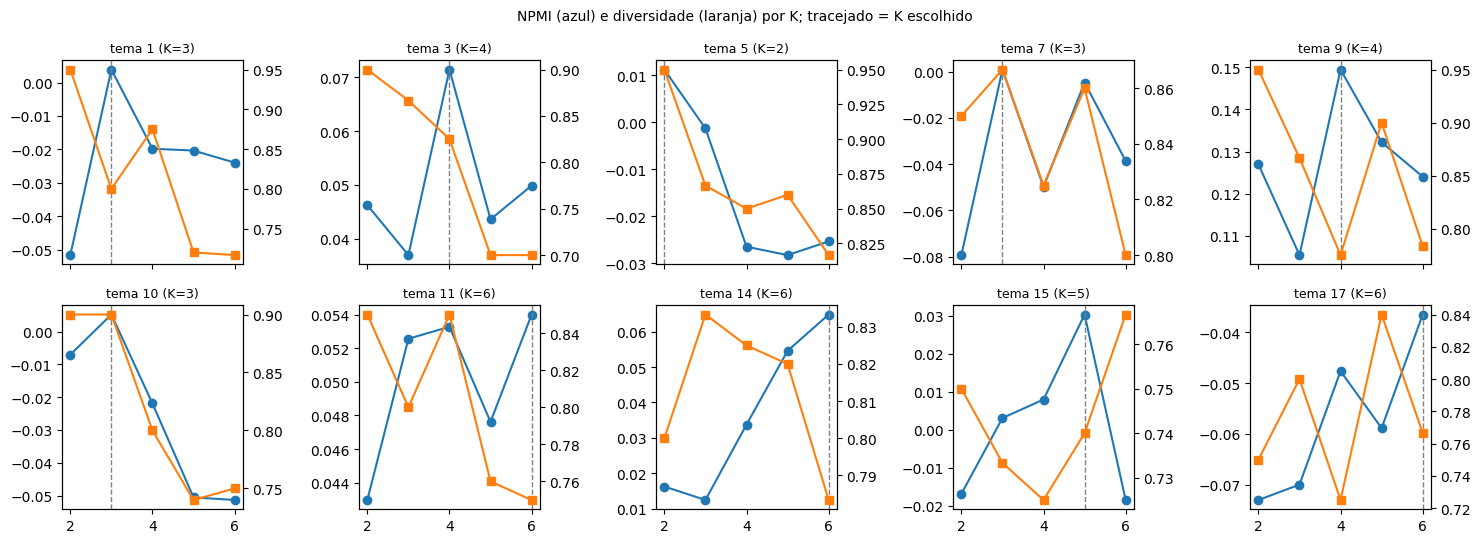

In [4]:
ncol = (len(TEMAS) + 1) // 2
fig, axes = plt.subplots(2, ncol, figsize=(3 * ncol, 5.5), sharex=True, squeeze=False)
for ax, t in zip(axes.flat, TEMAS):
    grid = pd.read_csv(LOCAL / f"topic{t:02d}" / "grid.csv")
    ax.plot(grid.k, grid.npmi, marker="o")
    ax2 = ax.twinx()
    ax2.plot(grid.k, grid.diversity, marker="s", color="tab:orange")
    k = int(resumo.set_index("tema").loc[t, "K"])
    ax.axvline(k, color="grey", ls="--", lw=1)
    ax.set_title(f"tema {t} (K={k})", fontsize=9)
for ax in list(axes.flat)[len(TEMAS):]:
    ax.axis("off")
fig.suptitle("NPMI (azul) e diversidade (laranja) por K; tracejado = K escolhido", fontsize=10)
fig.tight_layout()

## 3. Subtemas: termos e frases exemplares

Para cada subtema, as três frases de maior peso local, de vídeos distintos. Subtema `-1` =
frases sem palavras no dicionário local.

In [5]:
for t in TEMAS:
    pasta = LOCAL / f"topic{t:02d}"
    sub = pd.read_csv(pasta / "topics.csv")
    res = pd.read_csv(pasta / "nmf_results.csv", dtype={"sent_id": str, "post_id": str})
    res["peso_local"] = [max(json.loads(d)) if json.loads(d) else 0.0
                         for d in res.local_topic_distribution]
    print(f"\n################ Tema global {t} ({len(res)} frases)")
    for _, s in sub.iterrows():
        print(f"\n  -- {t}.{s.topic_id} ({s.n_sentences} frases): {s.top_terms}")
        top = (res.loc[res.local_topic_id == s.topic_id]
                  .sort_values("peso_local", ascending=False)
                  .drop_duplicates("post_id").head(3))
        for _, r in top.iterrows():
            print(f"     [{r.peso_local:.2f}|{r.product_category}] {r.sentence[:150]}")


################ Tema global 1 (6104 frases)

  -- 1.0 (2234 frases): quality, build, look, laptop, get, device, price, feel, overall, performance
     [1.00|laptop] It's just overall well built, good performance for the money.
     [1.00|phone] Maybe even an A plus on build quality.
     [1.00|phone] The call quality is clean but it's nothing super special.

  -- 1.1 (1957 frases): pretty, look, display, actually, nice, big, cool, camera, feel, color
     [1.00|laptop] You can find it pretty much anywhere.
     [1.00|phone] Which again, that's pretty impressive for a mid-ranger.
     [1.00|laptop] The webcam is pretty much garbage.

  -- 1.2 (1803 frases): sound, speaker, loud, camera, get, actually, laptop, face, great, port
     [1.00|headphone] So overall I was happy with the sound.
     [1.00|headphone] Now this is kind of so coming, but these nine microphones on here do a fantastic job with white noise and with a surprisingly natural sound to it.
     [1.00|laptop] It's loud and

     [1.00|laptop] and I think it's a really good laptop, especially for the money.
     [1.00|laptop] on the back runs along the full width of the device and they call this their Pulsar heatsink.
     [1.00|laptop] now on the back of this device is a rear mounted expansion Bay.

  -- 10.1 (799 frases): people, look, buy, apple, feel, keyboard, want, love, work, well
     [1.00|phone] But a lot of people will never notice because they also will never update their router.
     [1.00|phone] It's not awful, but sorry, selfie people.
     [1.00|laptop] And it's not something that I think will appear for most people's usage scenarios.

  -- 10.2 (2162 frases): actually, phone, big, price, point, pretty, get, time, year, apple
     [1.00|phone] Well I'll tell you, but let's start with the design though, just because I think it's actually the least ultra thing about this phone
     [1.00|phone] I think they could have easily kept the headphone jack around on this phone and not have had a prob


################ Tema global 15 (6308 frases)

  -- 15.0 (909 frases): use, touch, warm, feel, pad, light, cool, deck, device, get
     [1.00|laptop] Aces has refined its approach with the use of Sarah Luminum, a material that blends ceramic and aluminum to achieve a balance between durability and l
     [1.00|laptop] it doesn't have a usba port to plug in my mouse, which uses usba and most do I had to use.
     [1.00|laptop] it only uses the 160 MHz.

  -- 15.1 (1104 frases): great, key, color, device, function, light, speaker, work, look, quality
     [1.00|headphone] I picked them up because they already kind of have a great reputation.
     [1.00|laptop] They have great thermal systems.
     [1.00|phone] I mean, it's not a great looking video, but it's okay.

  -- 15.2 (1199 frases): trackpad, comfortable, nice, type, good, screen, accurate, work, super, display
     [1.00|headphone] Doesn't get sweaty like leather it's nice
     [1.00|laptop] The trackpad is, well technically it'

## 4. Montar a amostra cega para revisão humana

Junta NMF global e local por `sent_id`, marca o léxico de pedido/queixa, gera os rankings
(tema, léxico, combinação, aleatório) e a amostra cega em
`04-requirements/data/output/topicos_requisitos/`. Nenhuma frase é rotulada como requisito:
`requirement_candidate` fica vazio para a anotação humana (guia em
`04-requirements/guia_anotacao_rq4.md`).

Antes de anotar, veja a idealização §5.3C (empate do ranking por tema) e §4.7A (protocolo de
teste).

In [6]:
sys.path.insert(0, str(ROOT / "04-requirements"))
from nmf_requirement_review import run_nmf_review

SAIDA = (ROOT / "04-requirements" / "data" / "output" / "topicos_requisitos"
         / (FINAL.get("review_output") or f"{RUN.name}_revisao"))
if (SAIDA / "metadata.json").exists():
    # A revisão nunca sobrescreve: apague a pasta para regerar (isso muda a amostra cega).
    print("Revisão já existe, reabrindo:", SAIDA)
    resumo_revisao = json.loads((SAIDA / "metadata.json").read_text(encoding="utf-8"))
else:
    resumo_revisao = run_nmf_review(
        RUN, TEMAS, SAIDA, local_subdir=FINAL["local_subdir"],
        expected_count=FINAL.get("expected_sentences"),
        top_k=FINAL["top_k"], n_random=FINAL["n_random"], seed=SEED,
    )
    print("Revisão criada:", SAIDA)
{k: v for k, v in resumo_revisao.items() if k not in ("sources_sha256", "lexicon")}

Revisão já existe, reabrindo: D:\Documentos\youtube_metadata_collection\04-requirements\data\output\topicos_requisitos\nmf_global_sentence_k20_20261005_221423_revisao


{'pipeline': 'nmf_global_sentence_to_local_nmf_final',
 'global_run': 'D:\\Documentos\\youtube_metadata_collection\\03-topic-modeling\\data\\output\\youtube_sent\\nmf_global\\nmf_global_sentence_k20_20261005_221423',
 'local_subdir': 'restricted_gensim',
 'selected_topics': [1, 3, 5, 7, 9, 10, 11, 14, 15, 17],
 'n_evidence': 57952,
 'n_unassigned_local': 711,
 'n_lex_hit': 1620,
 'n_blind': 212,
 'top_k': 50,
 'n_random': 100,
 'seed': 42,
 'review_status': 'aguardando_anotacao_humana',
 'topic_score': 'global_topic_weight * local_topic_weight; zero for local_topic_id=-1',
 'weight_semantics': 'normalized topic activations, not calibrated requirement probabilities'}